In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

import cvTools.cv_interaction as cst

# Histogram Equalization

In [17]:
cst.show([cv.imread('data/NV/ISIC_0000015.jpg')])

In [19]:
ref = cv.imread('data/NV/ISIC_0000015.jpg')
prova = cv.imread('data/NV/ISIC_0000007.jpg')
cst.show([hist_match(prova, ref), prova, ref], ['matched', 'original', 'reference'])

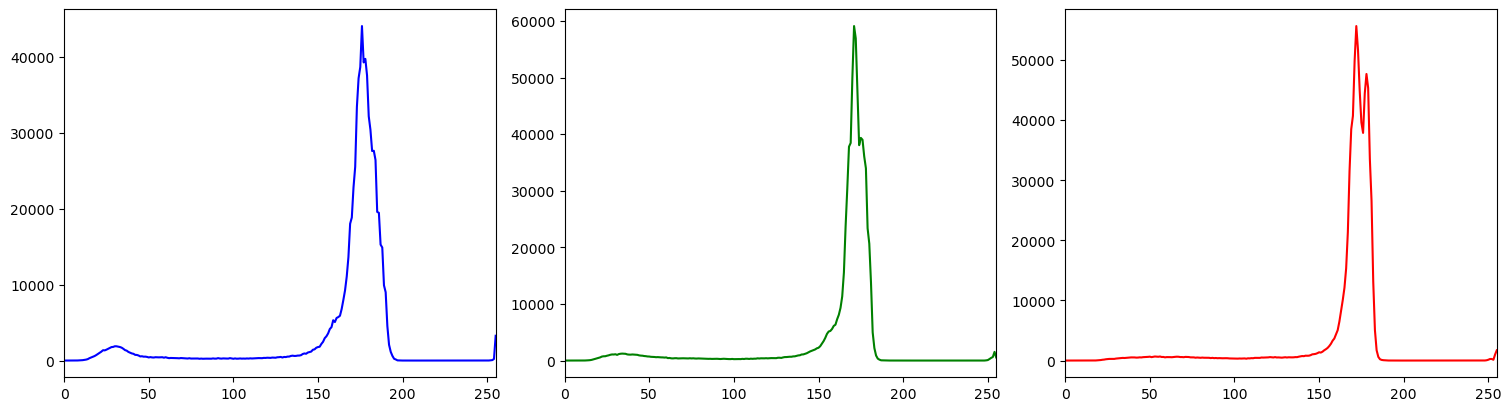

In [9]:
img_path = 'data/NV/ISIC_0000001.jpg'
img = cv.imread(img_path)
hists = [cv.calcHist([img], [i], None, [256], [0, 256]) for i in range(img.shape[-1])]

fig, ax = plt.subplots(1, 3, figsize=(15,4), layout='constrained')
for i, c in enumerate(('b', 'g', 'r')):
    ax[i].plot(hists[i], c=c)
    ax[i].set_xlim((0, 255))
plt.show()

---

In [99]:
img_path = 'data/MEL/ISIC_0014862_downsampled.jpg'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
mask = cv.inRange(img, (0, 110, 50), (23, 255, 210))
img = cv.bitwise_and(img, img, mask=mask)
img = cv.cvtColor(img, cv.COLOR_HSV2BGR)
img = cv.cvtColor(img, cv.COLOR_BGR2LAB)
hists = [cv.calcHist([img], [i], mask, [256], [0, 256]) for i in range(img.shape[-1])]

In [100]:
# Histogram to normalize
fig, ax = plt.subplots(figsize=(8,4), dpi=100, layout='constrained')
fig.suptitle('L channel Histogram')
ax.plot(hists[0], c='k')
ax.set_xlim((0, 255))
ax.set_xlabel('Values')
ax.set_ylabel('Pixels')
canvas = plt.get_current_fig_manager().canvas
plt.close()
canvas.draw()
hist_img = np.frombuffer(canvas.buffer_rgba(), dtype='uint8')
hist_img = hist_img.reshape(canvas.get_width_height()[::-1] + (4,))
hist_img = cv.cvtColor(hist_img, cv.COLOR_RGB2BGR)

In [101]:
hist_img = cv.resize(hist_img, (img.shape[1], hist_img.shape[0]))
shower = np.vstack((hist_img, img))

In [102]:
ct.show(shower)

In [103]:
lab_hist = [cv.calcHist([norm], [i], mask, [256], [0, 256]) for i in range(img.shape[-1])]

# Histogram to normalize
fig, ax = plt.subplots(layout='constrained')
fig.suptitle('L channel Histogram')
ax.plot(lab_hist[0], c='k')
ax.set_xlim((0, 255))
ax.set_xlabel('Values')
ax.set_ylabel('Pixels')
plt.close()

In [104]:
norm = np.copy(img)
norm[..., 0] = cv.equalizeHist(norm[..., 0])
norm = cv.cvtColor(norm, cv.COLOR_LAB2BGR)
img = cv.cvtColor(img, cv.COLOR_LAB2BGR)
shower = np.hstack((img, norm))
ct.show(shower)

# CLAHE

In [7]:
# Reading image
img_path = 'data/NV/ISIC_0000051_downsampled.jpg'
img = cv.imread(img_path)

# Thresholding
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
mask = cv.inRange(img, (0, 110, 50), (23, 255, 210))
masked = cv.bitwise_and(img, img, mask=mask)
img = cv.cvtColor(img, cv.COLOR_HSV2BGR)
masked = cv.cvtColor(masked, cv.COLOR_HSV2BGR)

# filtering
bil = cv.bilateralFilter(masked, d=9, sigmaColor=10, sigmaSpace=39)

# CLAHE
# cl = cv.cvtColor(np.copy(img), cv.COLOR_BGR2LAB)
cl = cv.cvtColor(bil, cv.COLOR_BGR2LAB)
clahe = cv.createCLAHE(clipLimit=2)
clL = clahe.apply(cl[..., 0])
cl[..., 0] = clL
cl_hist = cv.calcHist([cl], [0], mask, [256], [0, 256])
cl = cv.cvtColor(cl, cv.COLOR_LAB2BGR)
ct.show([np.hstack((masked, cl)), img], ['processed', 'original'])

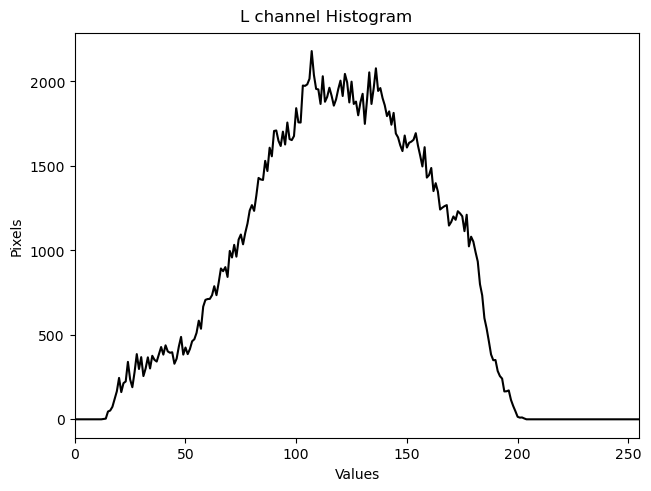

In [123]:
# Histogram to normalize
fig, ax = plt.subplots(layout='constrained')
fig.suptitle('L channel Histogram')
ax.plot(cl_hist, c='k')
ax.set_xlim((0, 255))
ax.set_xlabel('Values')
ax.set_ylabel('Pixels')
plt.show()